# 03b · 句向量 + K-means（表示方法对比）

03 用 TF-IDF 失败了，诊断出的原因是短文本词共现太稀疏（81.9% 的评论两两无共同词）。
本 notebook 换**句向量**（`shibing624/text2vec-base-chinese`，768 维，mean pooling + L2 归一化）
重跑同一套流程，看换表示方法能否救回来。

句向量确实能解决词共现问题，例如：

| 句对 | TF-IDF 余弦 | 句向量余弦 |
|---|---|---|
| 「王老吉太甜了，纯糖水」vs「这个跟糖水一样甜」 | ≈ 0 (无共同词) | **0.784** |
| 「王老吉太甜了，纯糖水」vs「价格有点贵」 | 0 | 0.339 |

### 止损判据（本次预先设定，不事后调整）

选定 K 后，满足**任一**条即判定失败，不再尝试第三种表示方法：

1. 轮廓系数 < **0.10**
2. `n_init=1` 三 seed 平均 ARI < **0.50**（即结构不稳）

流程与 03 完全一致：K 扫描 2-10、最小簇 ≥ 20 硬约束、`n_init=10` 与 `n_init=1` 双轨稳定性检查。
两种表示方法的结果并列保留，作为「数据不支持聚类」的证据。

In [1]:
import sys, warnings
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from matplotlib.font_manager import FontProperties
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             adjusted_rand_score, adjusted_mutual_info_score)
from sklearn.metrics.pairwise import cosine_distances, cosine_similarity
warnings.filterwarnings('ignore')

PROJ = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(PROJ / 'src'))
import text_utils as T

PROC = PROJ / 'data' / 'processed'
FIG  = PROJ / 'outputs' / 'figures'

font = T.get_cjk_font(verbose=True)          # 跨平台中文字体，含回退
plt.rcParams['figure.dpi'] = 110

df = pd.read_csv(PROC / 'comments_sentiment.csv', encoding='utf-8-sig',
                 parse_dates=['created_at'])
df['tokens'] = df['tokens'].fillna('')

DATASETS = {
    'primary': dict(name='主结果·2023+相关集', mask=df['is_primary']),
    'control': dict(name='对照·2023+全量',     mask=df['recent']),
}
MIN_CLUSTER   = 20
K_RANGE       = range(2, 11)
SEEDS         = [0, 7, 2024]
SIL_FLOOR     = 0.10     # 止损线 1
ARI_FLOOR     = 0.50     # 止损线 2（n_init=1）

for k, v in DATASETS.items():
    print(f"{k:8s} {v['name']:22s} n = {int(v['mask'].sum())}")

中文字体: SimHei
primary  主结果·2023+相关集           n = 260
control  对照·2023+全量             n = 523


## 1. 计算句向量

对全部 881 条算一次，两个数据集共用。

In [2]:
import torch
from transformers import AutoTokenizer, AutoModel

EMB_MODEL = 'shibing624/text2vec-base-chinese'
etok = AutoTokenizer.from_pretrained(EMB_MODEL)
emdl = AutoModel.from_pretrained(EMB_MODEL).eval()
print('模型 :', EMB_MODEL, '| 维度 :', emdl.config.hidden_size)


def encode(texts, bs=32, max_len=256):
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), bs):
            b = etok(texts[i:i + bs], return_tensors='pt', padding=True,
                     truncation=True, max_length=max_len)
            h = emdl(**b).last_hidden_state
            m = b['attention_mask'].unsqueeze(-1).float()
            v = (h * m).sum(1) / m.sum(1)                       # mean pooling
            out.append(torch.nn.functional.normalize(v, dim=1))  # L2 归一化
    return torch.cat(out).numpy()


EMB = encode(df['content_clean'].astype(str).tolist())
df_idx = {k: np.where(v['mask'].values)[0] for k, v in DATASETS.items()}
print('句向量矩阵 :', EMB.shape)

# 与 TF-IDF 的稀疏性对比
print()
print('=== 两种表示方法的文档相似度对比 ===')
rows = []
for key, v in DATASETS.items():
    sub = df[v['mask']]
    Xt = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False,
                         min_df=3, max_df=0.6).fit_transform(sub['tokens'])
    St = cosine_similarity(Xt); np.fill_diagonal(St, np.nan)
    Se = cosine_similarity(EMB[df_idx[key]]); np.fill_diagonal(Se, np.nan)
    rows.append({'数据集': v['name'], 'n': Xt.shape[0],
                 'TFIDF 维度': Xt.shape[1], '句向量维度': EMB.shape[1],
                 'TFIDF 相似度均值': round(float(np.nanmean(St)), 4),
                 '句向量 相似度均值': round(float(np.nanmean(Se)), 4),
                 'TFIDF 零相似文档对%': round(float(np.nanmean(St == 0) * 100), 1),
                 '句向量 零相似文档对%': round(float(np.nanmean(Se == 0) * 100), 1)})
print(pd.DataFrame(rows).T.to_string())

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

模型 : shibing624/text2vec-base-chinese | 维度 : 768


句向量矩阵 : (881, 768)

=== 两种表示方法的文档相似度对比 ===
                          0           1
数据集            主结果·2023+相关集  对照·2023+全量
n                       260         523
TFIDF 维度                185         344
句向量维度                   768         768
TFIDF 相似度均值          0.0358      0.0134
句向量 相似度均值            0.5569      0.4733
TFIDF 零相似文档对%          81.9        93.4
句向量 零相似文档对%             0.0         0.0


## 2. K 扫描（同 03 的规则：最小簇 ≥ 20）

In [3]:
def scan_k(X, k_range=K_RANGE, seed=42):
    out = []
    for k in k_range:
        km = KMeans(n_clusters=k, n_init=10, random_state=seed).fit(X)
        sizes = np.bincount(km.labels_, minlength=k)
        out.append({'K': k, 'inertia': round(float(km.inertia_), 2),
                    '轮廓系数': round(float(silhouette_score(X, km.labels_,
                                                          metric='cosine')), 4),
                    '最小簇': int(sizes.min()), '最大簇': int(sizes.max()),
                    '可用': '是' if sizes.min() >= MIN_CLUSTER else '否'})
    return pd.DataFrame(out)


scans_emb, scans_tfidf, mats_emb, mats_tfidf, vecs_tfidf = {}, {}, {}, {}, {}
for key, v in DATASETS.items():
    sub = df[v['mask']]
    Xe = EMB[df_idx[key]]
    vec = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False,
                          min_df=3, max_df=0.6)
    Xt = vec.fit_transform(sub['tokens'])
    mats_emb[key], mats_tfidf[key], vecs_tfidf[key] = Xe, Xt, vec
    scans_emb[key], scans_tfidf[key] = scan_k(Xe), scan_k(Xt)

    print('=' * 74)
    print(f"{v['name']}  n = {len(sub)}")
    print('\n--- 句向量 (768 维) ---')
    print(scans_emb[key].to_string(index=False))
    print('\n--- TF-IDF (对照，与 03 一致) ---')
    print(scans_tfidf[key].to_string(index=False))
    print()

主结果·2023+相关集  n = 260

--- 句向量 (768 维) ---
 K  inertia   轮廓系数  最小簇  最大簇 可用
 2   104.02 0.1617  121  139  是
 3    98.21 0.1498   65  109  是
 4    94.15 0.1576   30   93  是
 5    91.33 0.1349   21   67  是
 6    89.10 0.1394   23   63  是
 7    87.10 0.1245   19   53  否
 8    86.16 0.1105   17   59  否
 9    84.05 0.1076   15   43  否
10    82.28 0.1095    5   40  否

--- TF-IDF (对照，与 03 一致) ---
 K  inertia   轮廓系数  最小簇  最大簇 可用
 2   228.47 0.0581   73  187  是
 3   221.51 0.0671   12  181  否
 4   214.98 0.0843   12  154  否
 5   210.86 0.0939   12  137  否
 6   207.55 0.0770   10  134  否
 7   202.77 0.1106   12  117  否
 8   198.71 0.1211   11  102  否
 9   196.08 0.1249    3   98  否
10   194.58 0.0997    3  108  否



对照·2023+全量  n = 523

--- 句向量 (768 维) ---
 K  inertia   轮廓系数  最小簇  最大簇 可用
 2   253.65 0.1305  210  313  是
 3   244.42 0.0798  146  219  是
 4   238.81 0.0613   84  157  是
 5   234.56 0.0568   69  140  是
 6   230.62 0.0472   55  144  是
 7   228.52 0.0344   43  127  是
 8   225.87 0.0394   23  140  是
 9   224.07 0.0598   22  115  是
10   221.34 0.0459   20   89  是

--- TF-IDF (对照，与 03 一致) ---
 K  inertia   轮廓系数  最小簇  最大簇 可用
 2   451.15 0.0278   72  451  是
 3   444.66 0.0320   42  417  是
 4   443.55 0.0311    4  421  否
 5   434.34 0.0411   10  385  否
 6   430.51 0.0378   16  377  否
 7   428.83 0.0401    4  408  否
 8   422.22 0.0553    4  335  否
 9   416.92 0.0532   12  343  否
10   415.16 0.0576    4  368  否



## 3. 对比图：两种表示方法的肘部法 / 轮廓系数 / 最小簇规模

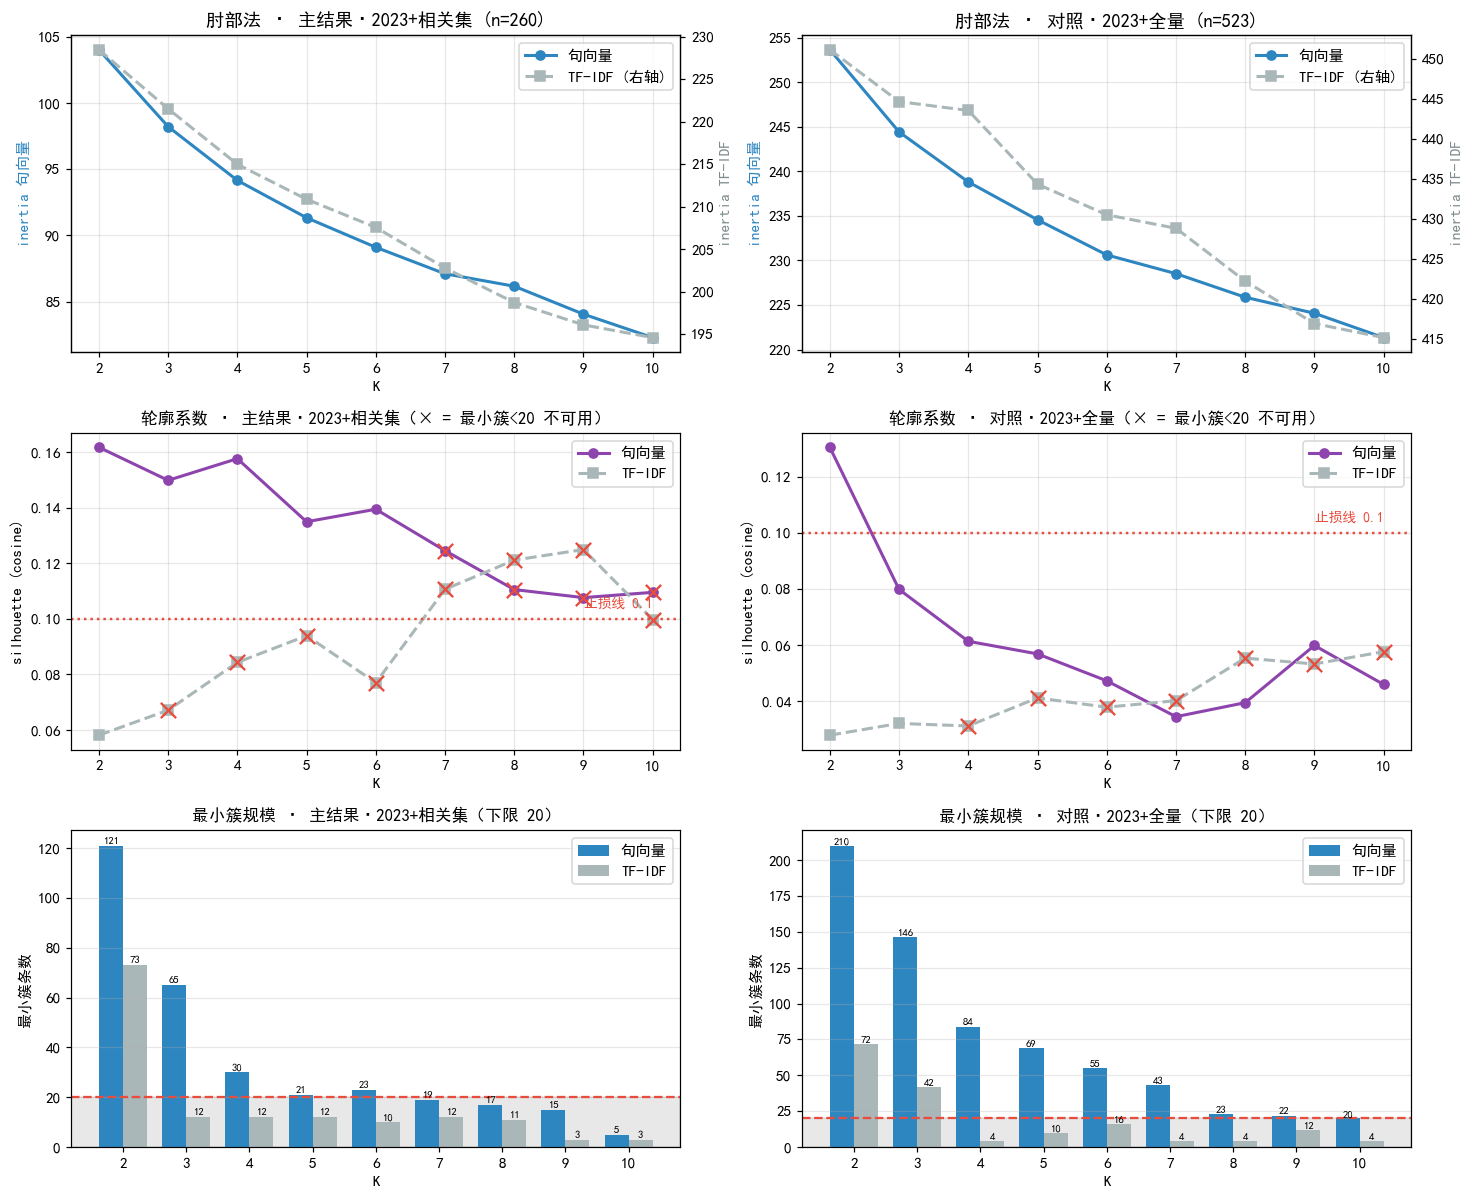

=== 主结果·2023+相关集 · 句向量 ===
  可用候选 K : [2, 3, 4, 5, 6]
  排除的 K   : [7, 8, 9, 10]
  选定 K = 2  轮廓系数 = 0.1617  最小簇 = 121

=== 对照·2023+全量 · 句向量 ===
  可用候选 K : [2, 3, 4, 5, 6, 7, 8, 9, 10]
  排除的 K   : []
  选定 K = 2  轮廓系数 = 0.1305  最小簇 = 210



In [4]:
fig, axes = plt.subplots(3, 2, figsize=(13.5, 11))
for j, (key, v) in enumerate(DATASETS.items()):
    se, st = scans_emb[key], scans_tfidf[key]

    a = axes[0, j]
    a.plot(se['K'], se['inertia'], marker='o', lw=2, color='#2E86C1', label='句向量')
    a2 = a.twinx()
    a2.plot(st['K'], st['inertia'], marker='s', lw=2, ls='--', color='#AAB7B8',
            label='TF-IDF (右轴)')
    a.set_title(f"肘部法 · {v['name']} (n={len(mats_emb[key])})",
                fontproperties=font, fontsize=12)
    a.set_xlabel('K', fontproperties=font)
    a.set_ylabel('inertia 句向量', fontproperties=font, color='#2E86C1')
    a2.set_ylabel('inertia TF-IDF', fontproperties=font, color='#7F8C8D')
    a.set_xticks(list(K_RANGE)); a.grid(alpha=.3)
    h1, l1 = a.get_legend_handles_labels(); h2, l2 = a2.get_legend_handles_labels()
    a.legend(h1 + h2, l1 + l2, prop=font, fontsize=8)

    a = axes[1, j]
    for s, lab, col, mk in [(se, '句向量', '#8E44AD', 'o'),
                            (st, 'TF-IDF', '#AAB7B8', 's')]:
        ok = s['可用'] == '是'
        a.plot(s['K'], s['轮廓系数'], marker=mk, lw=2, color=col, label=lab,
               ls='-' if lab == '句向量' else '--')
        a.scatter(s.loc[~ok, 'K'], s.loc[~ok, '轮廓系数'], marker='x', s=100,
                  color='#E74C3C', zorder=5)
    a.axhline(SIL_FLOOR, color='#E74C3C', ls=':', lw=1.6)
    a.text(K_RANGE[-1], SIL_FLOOR + 0.004, f'止损线 {SIL_FLOOR}', ha='right',
           fontproperties=font, color='#E74C3C', fontsize=9)
    a.set_title(f"轮廓系数 · {v['name']}（× = 最小簇<20 不可用）",
                fontproperties=font, fontsize=11)
    a.set_xlabel('K', fontproperties=font)
    a.set_ylabel('silhouette (cosine)', fontproperties=font)
    a.set_xticks(list(K_RANGE)); a.grid(alpha=.3); a.legend(prop=font, fontsize=8)

    a = axes[2, j]
    x, w = np.arange(len(se)), 0.38
    for off, s, lab, col in [(-w/2, se, '句向量', '#2E86C1'),
                             (w/2, st, 'TF-IDF', '#AAB7B8')]:
        bars = a.bar(x + off, s['最小簇'], w, label=lab, color=col)
        for b in bars:
            a.text(b.get_x()+b.get_width()/2, b.get_height()+0.8, str(int(b.get_height())),
                   ha='center', fontproperties=font, fontsize=7)
    a.axhline(MIN_CLUSTER, color='#E74C3C', ls='--', lw=1.5)
    a.axhspan(0, MIN_CLUSTER, color='grey', alpha=.18, zorder=0)
    a.set_xticks(x); a.set_xticklabels(se['K'])
    a.set_title(f"最小簇规模 · {v['name']}（下限 {MIN_CLUSTER}）",
                fontproperties=font, fontsize=11)
    a.set_xlabel('K', fontproperties=font)
    a.set_ylabel('最小簇条数', fontproperties=font)
    a.grid(alpha=.3, axis='y'); a.legend(prop=font, fontsize=8)

plt.tight_layout()
plt.savefig(FIG / '03b_representation_comparison.png', bbox_inches='tight')
plt.show()

CHOSEN = {}
for key, v in DATASETS.items():
    s = scans_emb[key]
    cand = s[s['可用'] == '是']
    print(f"=== {v['name']} · 句向量 ===")
    if cand.empty:
        CHOSEN[key] = None
        print('  无任何 K 满足最小簇 >= 20')
    else:
        best = cand.loc[cand['轮廓系数'].idxmax()]
        CHOSEN[key] = int(best['K'])
        print('  可用候选 K :', cand['K'].tolist())
        print('  排除的 K   :', s.loc[s['可用'] == '否', 'K'].tolist())
        print(f"  选定 K = {CHOSEN[key]}  轮廓系数 = {best['轮廓系数']}  "
              f"最小簇 = {int(best['最小簇'])}")
    print()

## 4. 稳定性检查（n_init=10 与 n_init=1 双轨）

In [5]:
stab = {}
for key, v in DATASETS.items():
    k = CHOSEN[key]
    print('=' * 74)
    print(f"{v['name']} · 句向量 | K = {k}")
    if k is None:
        print('  跳过'); continue
    X = mats_emb[key]
    rec = {}
    for n_init, tag in [(10, 'n_init=10（与主分析一致，偏乐观）'),
                        (1,  'n_init=1（暴露真实随机性）')]:
        labs = {sd: KMeans(n_clusters=k, n_init=n_init, random_state=sd).fit_predict(X)
                for sd in SEEDS}
        pairs = [(a, b) for i, a in enumerate(SEEDS) for b in SEEDS[i+1:]]
        tb = pd.DataFrame([{'对比': f'seed {a} vs {b}',
                            'ARI': round(adjusted_rand_score(labs[a], labs[b]), 4),
                            'AMI': round(adjusted_mutual_info_score(labs[a], labs[b]), 4)}
                           for a, b in pairs])
        print(f'\n  {tag}')
        print('   ', tb.to_string(index=False).replace('\n', '\n    '))
        print('    簇规模 :', {sd: sorted(np.bincount(l, minlength=k).tolist(), reverse=True)
                              for sd, l in labs.items()})
        m = tb['ARI'].mean()
        print(f'    平均 ARI = {m:.4f}  ->  ' +
              ('稳定' if m > 0.75 else '中等' if m > 0.5 else '不稳定'))
        rec['ARI_ninit10' if n_init == 10 else 'ARI_ninit1'] = round(m, 4)
    stab[key] = rec
    print()

主结果·2023+相关集 · 句向量 | K = 2

  n_init=10（与主分析一致，偏乐观）
                对比    ARI    AMI
       seed 0 vs 7 0.9846 0.9671
    seed 0 vs 2024 0.9243 0.8621
    seed 7 vs 2024 0.9095 0.8402
    簇规模 : {0: [144, 116], 7: [143, 117], 2024: [143, 117]}
    平均 ARI = 0.9395  ->  稳定

  n_init=1（暴露真实随机性）
                对比    ARI    AMI
       seed 0 vs 7 0.9542 0.9203
    seed 0 vs 2024 0.8802 0.8065
    seed 7 vs 2024 0.9243 0.8627
    簇规模 : {0: [135, 125], 7: [138, 122], 2024: [139, 121]}
    平均 ARI = 0.9196  ->  稳定

对照·2023+全量 · 句向量 | K = 2



  n_init=10（与主分析一致，偏乐观）
                对比    ARI    AMI
       seed 0 vs 7 1.0000 1.0000
    seed 0 vs 2024 0.9101 0.8523
    seed 7 vs 2024 0.9101 0.8523
    簇规模 : {0: [304, 219], 7: [304, 219], 2024: [314, 209]}
    平均 ARI = 0.9401  ->  稳定

  n_init=1（暴露真实随机性）
                对比    ARI    AMI
       seed 0 vs 7 1.0000 1.0000
    seed 0 vs 2024 0.8739 0.8213
    seed 7 vs 2024 0.8739 0.8213
    簇规模 : {0: [299, 224], 7: [299, 224], 2024: [316, 207]}
    平均 ARI = 0.9159  ->  稳定



## 5. 止损判定

按预先设定的两条判据，不事后调整阈值。

In [6]:
verdict = {}
print('止损判据 : 轮廓系数 >= %.2f  且  n_init=1 平均 ARI >= %.2f' % (SIL_FLOOR, ARI_FLOOR))
print()
for key, v in DATASETS.items():
    k = CHOSEN[key]
    if k is None:
        verdict[key] = '失败（无可用 K）'
        print(f"{v['name']:22s} -> {verdict[key]}")
        continue
    sil = float(scans_emb[key].set_index('K').loc[k, '轮廓系数'])
    ari1 = stab[key]['ARI_ninit1']
    f1 = sil < SIL_FLOOR
    f2 = ari1 < ARI_FLOOR
    verdict[key] = '失败' if (f1 or f2) else '通过'
    print(f"{v['name']:22s} K={k}")
    print(f"   轮廓系数      = {sil:.4f}   {'✗ 低于 %.2f' % SIL_FLOOR if f1 else '✓'}")
    print(f"   ARI(n_init=1) = {ari1:.4f}   {'✗ 低于 %.2f' % ARI_FLOOR if f2 else '✓'}")
    print(f"   -> 判定 : {verdict[key]}")
    print()

# 与 TF-IDF 并列
cmp_rows = []
for key, v in DATASETS.items():
    for tag, sc, st_ in [('TF-IDF', scans_tfidf[key], None),
                         ('句向量', scans_emb[key], stab.get(key))]:
        cand = sc[sc['可用'] == '是']
        if cand.empty:
            cmp_rows.append({'数据集': v['name'], '表示方法': tag, '选定K': None,
                             '轮廓系数': None, 'ARI(n_init=1)': None, '判定': '失败'})
            continue
        b = cand.loc[cand['轮廓系数'].idxmax()]
        cmp_rows.append({'数据集': v['name'], '表示方法': tag, '选定K': int(b['K']),
                         '轮廓系数': float(b['轮廓系数']),
                         'ARI(n_init=1)': st_['ARI_ninit1'] if st_ else None,
                         '判定': verdict[key] if tag == '句向量' else '失败(见 03)'})
CMP = pd.DataFrame(cmp_rows)
print('=== 两种表示方法并列（数据不支持聚类的证据）===')
print(CMP.to_string(index=False))
CMP.to_csv(PROC / 'clustering_representation_comparison.csv',
           index=False, encoding='utf-8-sig')
print()
print('已存证 :', (PROC / 'clustering_representation_comparison.csv').name)

止损判据 : 轮廓系数 >= 0.10  且  n_init=1 平均 ARI >= 0.50

主结果·2023+相关集           K=2
   轮廓系数      = 0.1617   ✓
   ARI(n_init=1) = 0.9196   ✓
   -> 判定 : 通过

对照·2023+全量             K=2
   轮廓系数      = 0.1305   ✓
   ARI(n_init=1) = 0.9159   ✓
   -> 判定 : 通过

=== 两种表示方法并列（数据不支持聚类的证据）===
         数据集   表示方法  选定K   轮廓系数  ARI(n_init=1)       判定
主结果·2023+相关集 TF-IDF    2 0.0581            NaN 失败(见 03)
主结果·2023+相关集    句向量    2 0.1617         0.9196       通过
  对照·2023+全量 TF-IDF    3 0.0320            NaN 失败(见 03)
  对照·2023+全量    句向量    2 0.1305         0.9159       通过

已存证 : clustering_representation_comparison.csv


## 6. 聚类内容检查

无论判定通过或失败，都把簇内容打出来看一眼——即使结构不稳，簇里是否有可识别的语义
本身也是信息。特征词用 **c-TF-IDF**（把每个簇当一篇文档，在簇之间算 TF-IDF），
因为句向量本身没有可读的「特征」。

In [7]:
results = {}
for key, v in DATASETS.items():
    k = CHOSEN[key]
    if k is None:
        continue
    sub = df[v['mask']].reset_index(drop=True).copy()
    X = mats_emb[key]
    km = KMeans(n_clusters=k, n_init=10, random_state=42).fit(X)
    sub['cluster'] = km.labels_
    sub['sil'] = silhouette_samples(X, km.labels_, metric='cosine')
    results[key] = dict(sub=sub, km=km, X=X, k=k)

    # c-TF-IDF：每簇拼成一篇文档
    docs = [' '.join(sub.loc[sub['cluster'] == c, 'tokens']) for c in range(k)]
    cvec = TfidfVectorizer(tokenizer=str.split, token_pattern=None, lowercase=False)
    Cm = cvec.fit_transform(docs)
    terms = np.array(cvec.get_feature_names_out())

    print('#' * 78)
    print(f"# {v['name']} · 句向量  |  K = {k}  |  n = {len(sub)}  |  判定 {verdict[key]}")
    print('#' * 78)
    for c in range(k):
        m = sub['cluster'] == c
        n_c = int(m.sum())
        row = Cm[c].toarray().ravel()
        top = [f'{terms[i]}({row[i]:.3f})' for i in row.argsort()[::-1][:20] if row[i] > 0]
        d = cosine_distances(X[m.values], km.cluster_centers_[c].reshape(1, -1)).ravel()
        rep = sub[m].iloc[np.argsort(d)[:5]]
        print(f"\n{'─'*74}")
        print(f"【簇 {c}】n={n_c} ({n_c/len(sub)*100:.1f}%)  平均轮廓={sub.loc[m,'sil'].mean():.3f}")
        print(f"  平台 : {sub.loc[m,'platform'].value_counts().to_dict()}")
        print(f"  情感 : {sub.loc[m,'sentiment'].value_counts().to_dict()}")
        print(f"  品类相关 : {int(sub.loc[m,'on_topic'].sum())}/{n_c} "
              f"({sub.loc[m,'on_topic'].mean()*100:.0f}%)")
        print('  c-TF-IDF top20 :')
        for i in range(0, len(top), 5):
            print('     ', '  '.join(top[i:i+5]))
        print('  代表评论 5 条 :')
        for _, rr in rep.iterrows():
            print(f"    - [{rr['platform']}/{rr['sentiment']}] {rr['content_clean'][:40]}")
    print()

##############################################################################
# 主结果·2023+相关集 · 句向量  |  K = 2  |  n = 260  |  判定 通过
##############################################################################

──────────────────────────────────────────────────────────────────────────
【簇 0】n=121 (46.5%)  平均轮廓=0.178
  平台 : {'B站': 58, '知乎': 49, '抖音': 14}
  情感 : {'负面': 53, '正面': 43, '中性': 25}
  品类相关 : 121/121 (100%)
  c-TF-IDF top20 :
      加多宝(0.590)  饮料(0.188)  上火(0.176)  好喝(0.151)  一口(0.141)
      广东(0.125)  红罐(0.125)  一种(0.123)  味道(0.123)  中药(0.106)
      皮糖(0.088)  功效(0.088)  风味(0.088)  降火(0.075)  那么(0.075)
      喜欢(0.075)  上来(0.071)  罗汉果(0.071)  可乐(0.071)  糖水(0.071)
  代表评论 5 条 :
    - [抖音/负面] 王老吉全国流行之前是有凉茶味的 流行之后基本不喝了，就一冰糖水。 不过看到广药拿
    - [抖音/正面] 现在的王老吉和加多宝都太甜了，奶茶果茶果汁啥的现在都有无糖、微糖、半糖、少糖、标
    - [知乎/负面] 最重要的一点，加多宝刚开始代言王老吉的时候，卖的是真凉茶，只有广东人和温州人上火
    - [B站/正面] 我一直认为这个才是正宗王老吉，这个从小喝到大，是王老吉的颗粒冲剂凉茶，这玩意是苦
    - [知乎/负面] 可以这么说，全国除两广外其他省市号称爱喝凉茶的，起码超过九成没喝过真正的凉茶，别

────────────────────────────────

##############################################################################
# 对照·2023+全量 · 句向量  |  K = 2  |  n = 523  |  判定 通过
##############################################################################

──────────────────────────────────────────────────────────────────────────
【簇 0】n=210 (40.2%)  平均轮廓=0.221
  平台 : {'B站': 105, '知乎': 74, '抖音': 31}
  情感 : {'负面': 102, '正面': 70, '中性': 38}
  品类相关 : 124/210 (59%)
  c-TF-IDF top20 :
      加多宝(0.493)  饮料(0.228)  好喝(0.190)  味道(0.173)  一口(0.173)
      上火(0.133)  喜欢(0.123)  一杯(0.120)  红罐(0.114)  广东(0.114)
      风味(0.107)  糖水(0.107)  喝完(0.107)  中药(0.093)  健康(0.085)
      红茶(0.080)  店员(0.080)  哪个(0.076)  不错(0.076)  无糖(0.067)
  代表评论 5 条 :
    - [抖音/正面] 现在的王老吉和加多宝都太甜了，奶茶果茶果汁啥的现在都有无糖、微糖、半糖、少糖、标
    - [抖音/负面] 王老吉全国流行之前是有凉茶味的 流行之后基本不喝了，就一冰糖水。 不过看到广药拿
    - [B站/正面] 我一直认为这个才是正宗王老吉，这个从小喝到大，是王老吉的颗粒冲剂凉茶，这玩意是苦
    - [知乎/负面] 可以这么说，全国除两广外其他省市号称爱喝凉茶的，起码超过九成没喝过真正的凉茶，别
    - [知乎/负面] 最重要的一点，加多宝刚开始代言王老吉的时候，卖的是真凉茶，只有广东人和温州人上火

──────────────────────────────────

## 7. PCA 散点图

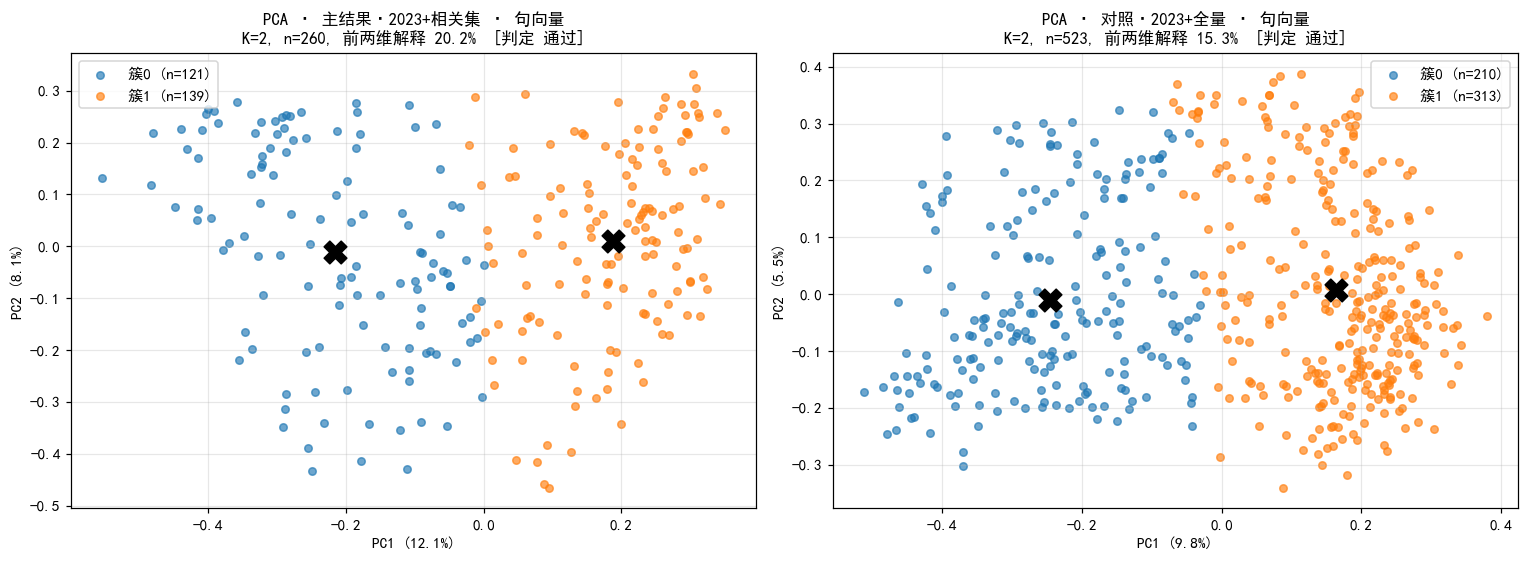

In [8]:
if results:
    fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 5.2))
    if len(results) == 1:
        axes = [axes]
    for a, (key, r) in zip(axes, results.items()):
        pca = PCA(n_components=2, random_state=42)
        xy = pca.fit_transform(r['X'])
        cen = pca.transform(r['km'].cluster_centers_)
        sizes = np.bincount(r['sub']['cluster'], minlength=r['k'])
        cmap = plt.get_cmap('tab10')
        for c in range(r['k']):
            m = r['sub']['cluster'] == c
            a.scatter(xy[m, 0], xy[m, 1], s=24, alpha=.65, color=cmap(c),
                      label=f'簇{c} (n={sizes[c]})')
        a.scatter(cen[:, 0], cen[:, 1], marker='X', s=220, c='black', zorder=5)
        ev = pca.explained_variance_ratio_
        a.set_title(f"PCA · {DATASETS[key]['name']} · 句向量\n"
                    f"K={r['k']}, n={len(r['sub'])}, 前两维解释 {ev.sum()*100:.1f}%  "
                    f"[判定 {verdict[key]}]", fontproperties=font, fontsize=11)
        a.set_xlabel(f'PC1 ({ev[0]*100:.1f}%)', fontproperties=font)
        a.set_ylabel(f'PC2 ({ev[1]*100:.1f}%)', fontproperties=font)
        a.legend(prop=font, fontsize=8); a.grid(alpha=.3)
    plt.tight_layout()
    plt.savefig(FIG / '03b_pca_scatter.png', bbox_inches='tight')
    plt.show()

## 8. 落盘

In [9]:
for key, r in results.items():
    p = PROC / f'clusters_emb_{key}.csv'
    cols = ['row_id', 'platform', 'keyword', 'created_at', 'year', 'on_topic',
            'content_clean', 'n_tokens', 'like_count', 'p_pos', 'sentiment',
            'topics', 'cluster', 'sil']
    r['sub'][[c for c in cols if c in r['sub'].columns]] \
        .to_csv(p, index=False, encoding='utf-8-sig')
    print('已写出 :', p.name, '|', len(r['sub']), '条 | K =', r['k'])

print()
print('图表 :')
for f in sorted(FIG.glob('03b_*.png')):
    print('  -', f.name, round(f.stat().st_size / 1024), 'KB')
print()
print('=== 最终判定 ===')
for key, v in DATASETS.items():
    print(f"  {v['name']:22s} 句向量 -> {verdict[key]}")
print()
if all(x.startswith('失败') for x in verdict.values()):
    print('两种表示方法（TF-IDF / 句向量）均失败 -> 按预设止损，不再尝试第三种表示方法。')
    print('结论：该数据集不支持可靠的无监督聚类，改走 04 的规则式话题交叉分析。')
else:
    print('至少一个数据集通过止损判据，详见上方逐簇内容。')

已写出 : clusters_emb_primary.csv | 260 条 | K = 2
已写出 : clusters_emb_control.csv | 523 条 | K = 2

图表 :
  - 03b_pca_scatter.png 104 KB
  - 03b_representation_comparison.png 197 KB

=== 最终判定 ===
  主结果·2023+相关集           句向量 -> 通过
  对照·2023+全量             句向量 -> 通过

至少一个数据集通过止损判据，详见上方逐簇内容。
